In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
well_id = "000d7d20"
horizon_path = f"../data/test/{well_id}__horizontal_well.csv"
type_path = f"../data/test/{well_id}__typewell.csv"

In [26]:
# Daten laden
df_horiz = pd.read_csv(horizon_path)
df_type = pd.read_csv(type_path)

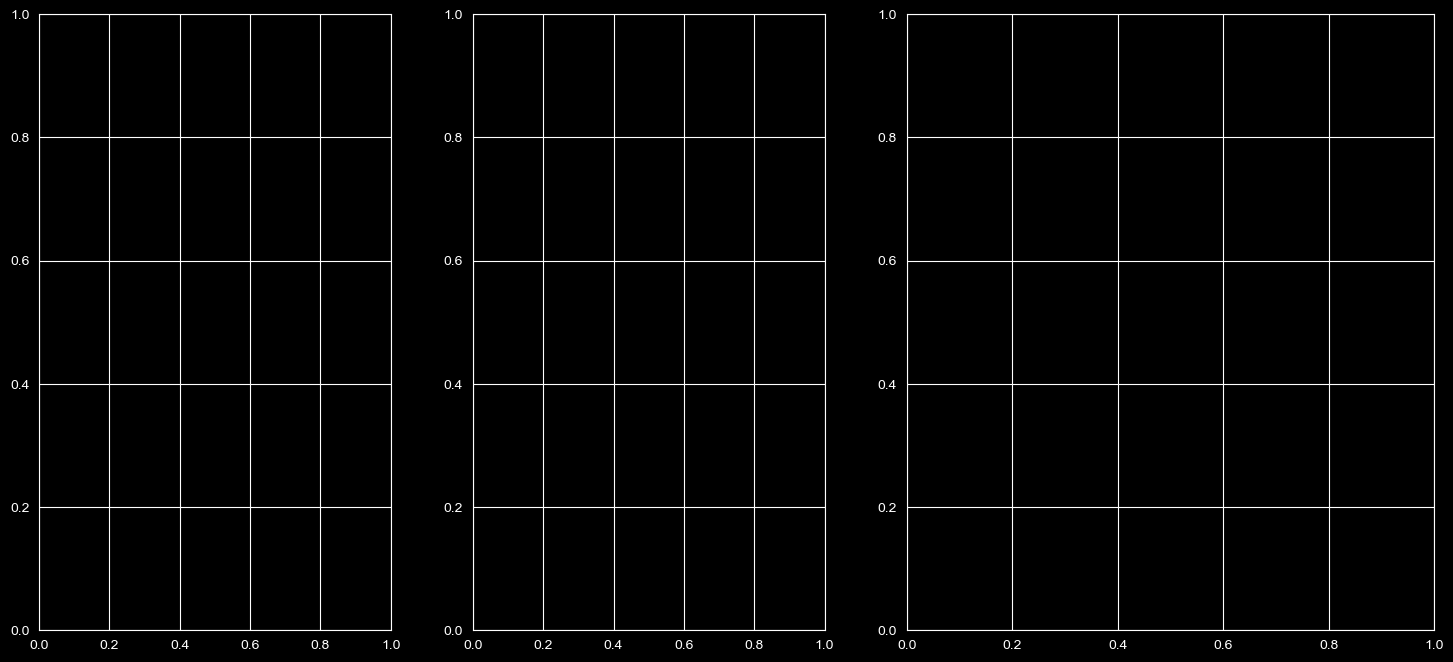

In [27]:
# Looking for evaluation zone
eval_start_idx = df_horiz['TVT_input'].isna().idxmax()
eval_start_md = df_horiz.loc[eval_start_idx, 'MD']

# Plotting Setup
fig, axes = plt.subplots(1, 3, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1, 1.5]})

In [28]:
# 1. Typewell (Vertical Reference)
axes[0].plot(df_type['GR'], df_type['TVT'], color='darkblue')
axes[0].invert_yaxis()
axes[0].set_title(f'Typewell {well_id}\nTVt vs GR')
axes[0].set_xlabel('Gamma Ray (GR)')
axes[0].set_ylabel('True Vertical Thickness (TVT)')
axes[0].grid(True, linestyle='--', alpha=0.6)

In [29]:
# 2. Horizontal Well (Sensor-Signal)
axes[1].plot(df_horiz['GR'], df_horiz['MD'], color='darkorange')
axes[1].axhline(y=eval_start_md, color='red', linestyle='--', label='Start Eval Zone (NaNs)')
axes[1].invert_yaxis()
axes[1].set_title('Horizontal Well\nMD vs GR')
axes[1].set_xlabel('Gamma Ray (GR)')
axes[1].set_ylabel('Measured Depth (MD)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

In [30]:
# 3. Drilling path and prediction zone
axes[2].plot(df_horiz['MD'], df_horiz['TVT_input'], color='green', linewidth=2, label='Bekanntes TVT_input')
axes[2].axvline(x=eval_start_md, color='red', linestyle='--', label='Start Eval Zone')
axes[2].axvspan(eval_start_md, df_horiz['MD'].max(), color='red', alpha=0.1, label='Zu prognostizierende Zone')
axes[2].set_title('Bohrpfad (MD vs TVT)\nWo müssen wir vorhersagen?')
axes[2].set_xlabel('Measured Depth (MD)')
axes[2].set_ylabel('TVT_input (Geologische Tiefe)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

In [32]:
plt.tight_layout()
plt.savefig('eda_plot_000d7d20.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"--- Bohrloch: {well_id} ---")
print(f"Bekannte TVT Datenpunkte: {eval_start_idx}")
print(f"Fehlende Datenpunkte (Evaluation): {len(df_horiz) - eval_start_idx}")

<Figure size 640x480 with 0 Axes>

--- Bohrloch: 000d7d20 ---
Bekannte TVT Datenpunkte: 1442
Fehlende Datenpunkte (Evaluation): 3836
